# MNIST Classifier from Scratch: Neural Networks Without the Magic

The goal of this notebook is to deeply explore the full mechanics of a neural network without any hidden abstractions.


### PyTorch Implementation

This is the reference implementation.


In [129]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [130]:
# Normalize and load MNIST datasets
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
train_set = datasets.MNIST(root="../data", train=True, download=True, transform=transform)
test_set = datasets.MNIST(root="../data", train=False, download=True, transform=transform)

# Create DataLoaders for mini-batch iterations
batch_size = 32
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

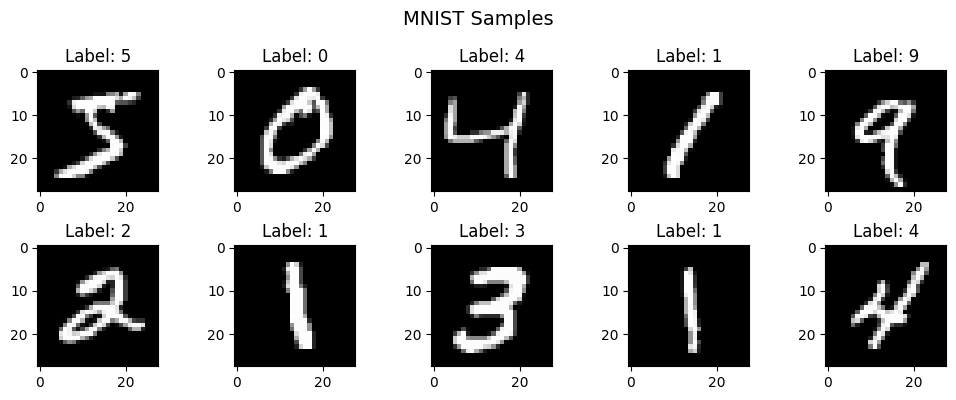

In [131]:
# Visualize image dataset
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flat):
    x_train, y_train = train_set[i]
    ax.imshow(x_train.squeeze(), cmap="gray")
    ax.set_title(f"Label: {y_train}")

plt.suptitle("MNIST Samples", fontsize=14)
plt.tight_layout()
plt.show()

In [132]:
# Define the model
class TorchNet(nn.Module):
    def __init__(self):
        super(TorchNet, self).__init__()
        self.l1 = nn.Linear(28 * 28, 128)
        self.l2 = nn.Linear(128, 64)
        self.l3 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        x = F.relu(self.l1(x))
        x = F.relu(self.l2(x))
        x = F.log_softmax(self.l3(x), dim=1)
        return x

In [125]:
model = TorchNet()
loss_func = nn.NLLLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0)

# Train the torch model
num_epochs = 10

for epoch in range(num_epochs):
    running_loss = 0.0
    correct = 0
    total = 0

    for x_train, y_train in train_loader:
        optimizer.zero_grad()
        output = model(x_train)
        loss = loss_func(output, y_train)
        loss.backward()
        optimizer.step()
  
        # Accumulate loss
        running_loss += loss.item()

        # Accumulate correct predictions
        predicted = output.argmax(dim=1)
        correct += (predicted == y_train).sum().item()
        total += y_train.shape[0]

    loss = running_loss / len(train_loader)
    acc = 100 * correct / total
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss:.4f}, Accuracy: {acc:.2f}%")

Epoch [1/10], Loss: 1.9183, Accuracy: 50.72%
Epoch [2/10], Loss: 0.8459, Accuracy: 80.45%
Epoch [3/10], Loss: 0.5052, Accuracy: 86.89%
Epoch [4/10], Loss: 0.4106, Accuracy: 88.71%
Epoch [5/10], Loss: 0.3668, Accuracy: 89.59%
Epoch [6/10], Loss: 0.3401, Accuracy: 90.28%
Epoch [7/10], Loss: 0.3205, Accuracy: 90.77%
Epoch [8/10], Loss: 0.3049, Accuracy: 91.22%
Epoch [9/10], Loss: 0.2918, Accuracy: 91.56%
Epoch [10/10], Loss: 0.2803, Accuracy: 91.90%


In [126]:
# Evaluate the torch model
correct = 0
total = 0

with torch.no_grad():
    for x_test, y_test in test_loader:
        output = model(x_test)
        predicted = output.argmax(dim=1)
        correct += (predicted == y_test).sum().item()
        total += y_test.shape[0]

print(f"Test Accuracy: {100 * correct / total}%")

Test Accuracy: 92.3%


### NumPy Implementation

No autograd. No `nn.Linear`. No hidden abstractions.


In [127]:
import numpy as np


def relu(z) -> np.ndarray:
    return np.maximum(0, z)


def relu_grad(z) -> np.ndarray:
    return (z > 0).astype(np.float32)


def log_softmax(z) -> np.ndarray:
    z_shift = z - np.max(z, axis=1, keepdims=True)
    logsumexp = np.log(np.sum(np.exp(z_shift), axis=1, keepdims=True))
    return z_shift - logsumexp


def nll_loss(log_probs, y) -> np.float32:
    n = y.shape[0]
    correct_probs = log_probs[np.arange(n), y]
    return -np.mean(correct_probs)


def nll_log_softmax_grad(log_probs, y) -> np.ndarray:
    # Combined gradient of NLL Loss and log_softmax
    # https://blog.ando.ai/posts/softmax-to-the-max/
    n = y.shape[0]
    grad = np.exp(log_probs)      # Compute softmax probabilities
    grad[np.arange(n), y] -= 1.0  # Subtract one-hot labels
    grad /= n                     # Average over batch
    return grad


class Layer:
    """
    A fully connected neural network layer.
    """
    def __init__(self, nin, nout):
        self.w = (np.random.randn(nin, nout) * np.sqrt(2 / nin)).astype(np.float32)
        self.b = np.zeros(nout, dtype=np.float32)
        self.dw = None
        self.db = None

    def parameters(self) -> list[np.ndarray]:
        return [self.w, self.b]


class PyNet:
    """
    A 3-layer feedforward neural network.
    """
    def __init__(self):
        self.l1 = Layer(28 * 28, 128)
        self.l2 = Layer(128, 64)
        self.l3 = Layer(64, 10)

    def forward_backward(self, x, y) -> np.float32:
        x = x.reshape(-1, 28 * 28)

        # Forward pass
        z1 = np.dot(x, self.l1.w) + self.l1.b
        a1 = relu(z1)
        z2 = np.dot(a1, self.l2.w) + self.l2.b
        a2 = relu(z2)
        z3 = np.dot(a2, self.l3.w) + self.l3.b
        log_probs = log_softmax(z3)
        loss = nll_loss(log_probs, y)

        # Backward pass
        dz3 = nll_log_softmax_grad(log_probs, y)

        # Gradient of l3
        self.l3.dw = np.dot(a2.T, dz3)
        self.l3.db = dz3.sum(axis=0)
        da2 = np.dot(dz3, self.l3.w.T)

        # Gradient of relu2
        dz2 = da2 * relu_grad(z2)

        # Gradient of l2
        self.l2.dw = np.dot(a1.T, dz2)
        self.l2.db = dz2.sum(axis=0)
        da1 = np.dot(dz2, self.l2.w.T)

        # Gradient of relu1
        dz1 = da1 * relu_grad(z1)

        # Gradient of l1
        self.l1.dw = np.dot(x.T, dz1)
        self.l1.db = dz1.sum(axis=0)
        
        return loss

    def predict(self, x) -> np.ndarray:
        x = x.reshape(-1, 28 * 28)
        z1 = np.dot(x, self.l1.w) + self.l1.b
        a1 = relu(z1)
        z2 = np.dot(a1, self.l2.w) + self.l2.b
        a2 = relu(z2)
        z3 = np.dot(a2, self.l3.w) + self.l3.b
        return np.argmax(z3, axis=1)

    def parameters(self) -> list[Layer]:
        return [self.l1, self.l2, self.l3]

In [128]:
class SGD:
    """
    Stochastic gradient descent optimizer.
    """
    def __init__(self, model: PyNet, lr: float):
        self.layers = model.parameters()
        self.lr = lr

    def step(self):
        for layer in self.layers:
            layer.w -= self.lr * layer.dw
            layer.b -= self.lr * layer.db

    def zero_grad(self):
        for layer in self.layers:
            layer.dw = None
            layer.db = None


model = PyNet()
optimizer = SGD(model, lr=0.001)

# Train the numpy model
num_epochs = 10

for epoch in range(num_epochs):
    running_loss = 0.0
    correct = 0
    total = 0

    for x_train, y_train in train_loader:
        x_train = x_train.numpy().astype(np.float32)
        y_train = y_train.numpy().astype(np.int32)

        optimizer.zero_grad()
        loss = model.forward_backward(x_train, y_train)
        optimizer.step()
        
        # Accumulate loss
        running_loss += loss
        
        # Accumulate correct predictions
        predicted = model.predict(x_train)
        correct += (predicted == y_train).sum()
        total += y_train.shape[0]

    loss = running_loss / len(train_loader)
    acc = 100 * correct / total
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss:.4f}, Accuracy: {acc:.2f}%")

Epoch [1/10], Loss: 0.9537, Accuracy: 72.04%
Epoch [2/10], Loss: 0.4228, Accuracy: 88.03%
Epoch [3/10], Loss: 0.3414, Accuracy: 90.22%
Epoch [4/10], Loss: 0.3001, Accuracy: 91.40%
Epoch [5/10], Loss: 0.2728, Accuracy: 92.20%
Epoch [6/10], Loss: 0.2520, Accuracy: 92.83%
Epoch [7/10], Loss: 0.2355, Accuracy: 93.31%
Epoch [8/10], Loss: 0.2218, Accuracy: 93.73%
Epoch [9/10], Loss: 0.2099, Accuracy: 94.14%
Epoch [10/10], Loss: 0.1999, Accuracy: 94.37%
